In [1]:
import numpy as np, pandas as pd, os
from pathlib import Path
from fastai.vision.all import *



/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
# Define data directories
train_path = Path("/kaggle/input/cassava-leaf-disease-classification/train_images")
test_path = Path("/kaggle/input/cassava-leaf-disease-classification/test_images")
df = pd.read_csv("/kaggle/input/cassava-leaf-disease-classification/train.csv")



In [3]:
# Verify files count (optional)
fns_train = get_image_files(train_path)
fns_test = get_image_files(test_path)
print(len(fns_train), len(fns_test))



18721 2676


In [4]:
# Transforms – corrected (no trailing comma so item_tfms is not a tuple)
item_tfms = RandomResizedCrop(460, min_scale=0.75)
batch_tfms = [
    *aug_transforms(size=224, max_warp=0, max_zoom=0.8),
    Normalize.from_stats(*imagenet_stats),
]



In [5]:
cassava = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=ColReader("image_id", pref=train_path),
    get_y=ColReader("label"),
    splitter=RandomSplitter(),
    item_tfms=item_tfms,
    batch_tfms=batch_tfms,
)



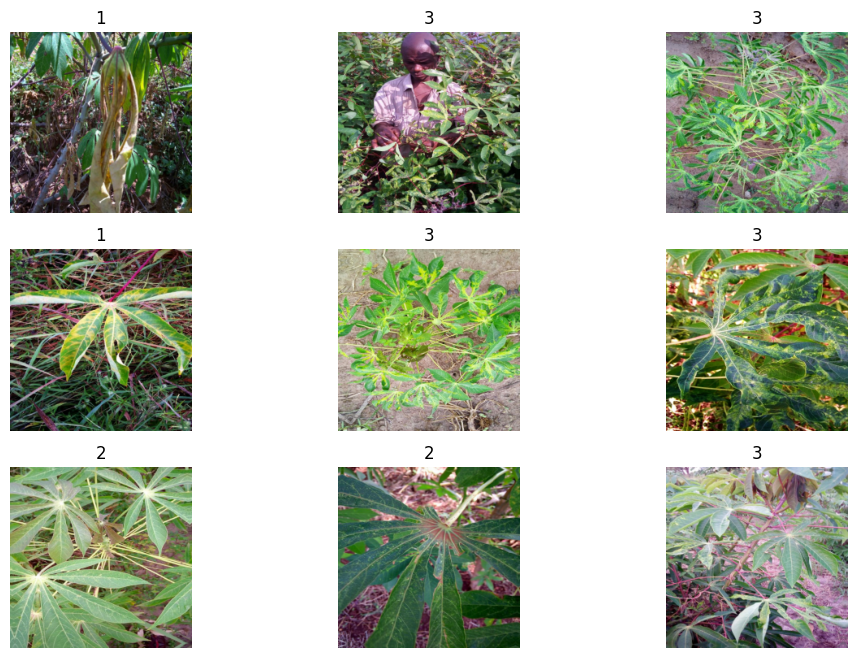

In [6]:
# Create DataLoaders
dls = cassava.dataloaders(df, bs=32)
dls.show_batch(max_n=9, figsize=(12, 8))



In [7]:
# Train a simple model (same architecture family as original intent)
learn = cnn_learner(dls, resnet34, metrics=accuracy)
learn.fine_tune(2)  # short training to produce a usable model



/usr/local/lib/python3.11/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 88.9MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,1.005910,0.794561,0.712340,00:39


epoch,train_loss,valid_loss,accuracy,time
0,0.673760,0.535221,0.810096,00:41
1,0.535383,0.482294,0.830662,00:40


In [8]:
# Prepare test dataloader
test_dl = dls.test_dl(fns_test)



In [9]:
# Get predictions on test set
test_pred = learn.get_preds(dl=test_dl)[0]



In [10]:
# Convert predictions to label strings
test_pred_max = test_pred.argmax(dim=1)
pred_labels = [dls.vocab[o] for o in test_pred_max]



In [11]:
# Build submission DataFrame with correct column names
sub = pd.DataFrame({"image_id": [p.name for p in test_dl.items], "label": pred_labels})



In [12]:
# Save submission file
sub.to_csv("submission.csv", index=False)
print("Submission saved to submission.csv, rows:", sub.shape[0])

Submission saved to submission.csv, rows: 2676
